In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
X = np.array([1,2,3,4,5]).reshape(-1,1)
X

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [3]:
y = np.array([50,55,65,78,89])
y

array([50, 55, 65, 78, 89])

In [4]:
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [5]:
Y_pred =model.predict(X)

In [6]:
print("Slope: ", model.coef_[0])

Slope:  10.100000000000001


In [7]:
print("Intercept: ",model.intercept_)

Intercept:  37.1


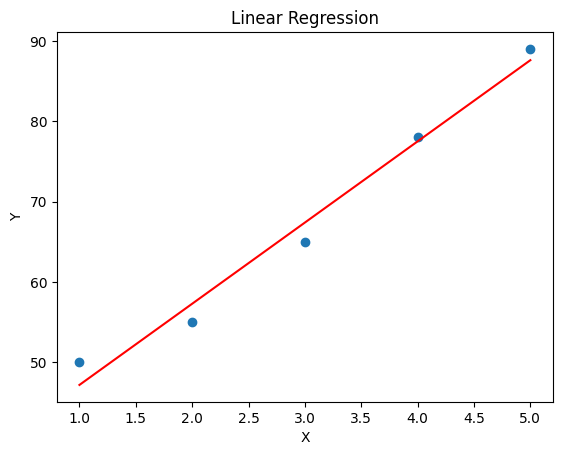

In [8]:
plt.scatter(X,y)
plt.plot(X,Y_pred,color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression')
plt.show()

Ex:Simple Linear Regression

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [10]:
dataset = pd.read_csv('/content/Salary_Data.csv')
dataset.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [11]:
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=0)

In [13]:
#Apply Linear Model
regressor = LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [14]:
#Make prediction
y_pred = regressor.predict(X_test)

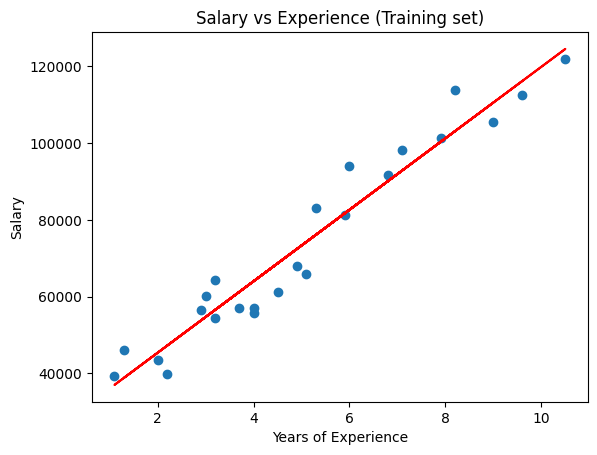

In [15]:
# Visualize training data
plt.scatter(X_train, y_train) # Data points
plt.plot(X_train, regressor.predict(X_train), color='red') #regression line
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()


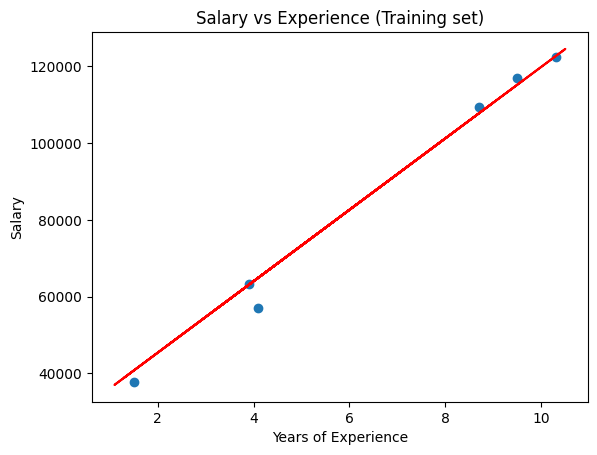

In [16]:
# Visualize testing data
plt.scatter(X_test,y_test)
plt.plot(X_train, regressor.predict(X_train), color='red')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [17]:
b =regressor.coef_
print("Coefficient= ",b)

Coefficient=  [9312.57512673]


In [18]:
a = regressor.intercept_
print("Intercept= ",a)

Intercept=  26780.09915062818


In [19]:
# Prediction
x = regressor.predict([[5]])
x

array([73342.97478427])

In [20]:
# MSE
metrics.mean_squared_error(y_test,y_pred)

12823412.298126549

In [21]:
# R-squared
metrics.r2_score(y_test,y_pred)

0.988169515729126

In [22]:
#Statistical summary
import statsmodels.api as sm

X_stats = sm.add_constant(X_train)

In [23]:
model = sm.OLS(y_train, X_stats).fit()

In [24]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     352.1
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           5.03e-15
Time:                        07:16:09   Log-Likelihood:                -242.89
No. Observations:                  24   AIC:                             489.8
Df Residuals:                      22   BIC:                             492.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.678e+04   2818.687      9.501      0.0

Ex: House Price Prediction

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [26]:
#Ex: House-prize
data = {
    'Area': [500, 800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800],
    'Price': [1500000, 2200000, 2800000, 3200000, 4000000, 4500000, 5000000, 5500000, 6200000, 7000000]
}
df = pd.DataFrame(data)


In [27]:
df.shape

(10, 2)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Area    10 non-null     int64
 1   Price   10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


In [29]:
df.describe()

,Area,Price
count,10.000000,1.000000e+01
mean,1630.000000,4.190000e+06
std,758.727004,1.781042e+06
min,500.000000,1.500000e+06
25%,1050.000000,2.900000e+06
50%,1650.000000,4.250000e+06
75%,2150.000000,5.375000e+06
max,2800.000000,7.000000e+06


In [30]:
X = df[['Area']].values
y = df['Price'].values

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [33]:
y_pred = model.predict(X_test)

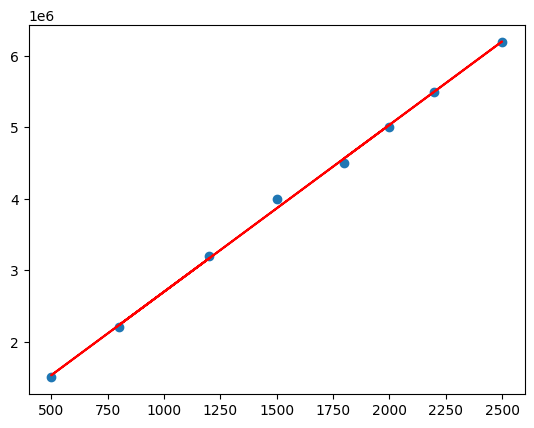

In [34]:
# Training data
plt.scatter(X_train,y_train)
plt.plot(X_train, model.predict(X_train), color='red')


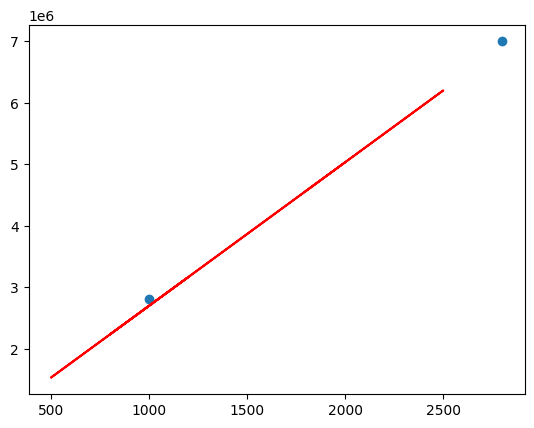

In [35]:
#Testing data
plt.scatter(X_test,y_test)
plt.plot(X_train, model.predict(X_train), color='red')


In [36]:
print("Coefficient=",model.coef_)
print("Intercept=",model.intercept_)

Coefficient= [2336.29300777]
Intercept= 362042.1753607113


In [37]:
# y = 2336.29X + 362042.17

print("MSE= ",metrics.mean_squared_error(y_test,y_pred))
print("R-square= ", metrics.r2_score(y_test,y_pred))

MSE=  9808315091.999111
R-square=  0.997775892269388


Ex: Multi Linear Regression

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [48]:
dataset = pd.read_csv('/content/50_Startups.csv')

In [40]:
dataset.shape

(50, 5)

In [49]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [50]:
dataset.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [51]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [52]:
#Apply OnehotEncoder

ct = ColumnTransformer(
    transformers=[('encoder',OneHotEncoder(drop='first'),[3])],
    remainder='passthrough'
)

In [53]:
X = np.array(ct.fit_transform(X))

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=0)

In [56]:
regressor = LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [59]:
y_pred = regressor.predict(X_test)

In [61]:
mse = metrics.mean_squared_error(y_test,y_pred)
mse

83502864.03250548

In [64]:
r2 = metrics.r2_score(y_test,y_pred)
r2

0.9347068473282987

In [65]:
pd.DataFrame({'Actual': y_test, 'Predicted':y_pred})

,Actual,Predicted
0,103282.38,103015.201598
1,144259.40,132582.277608
2,146121.95,132447.738452
3,77798.83,71976.098513
4,191050.39,178537.482211
5,105008.31,116161.242302
6,81229.06,67851.692097
7,97483.56,98791.733747
8,110352.25,113969.435330
9,166187.94,167921.065696


Ex:

In [67]:
import numpy as np
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

In [68]:
np.random.seed(0)
X = 6 * np.random.rand(100, 1)-2
y = 0.5 * X**2 + np.random.randn(100, 1)

Text(0.5, 1.0, 'Original dataset')

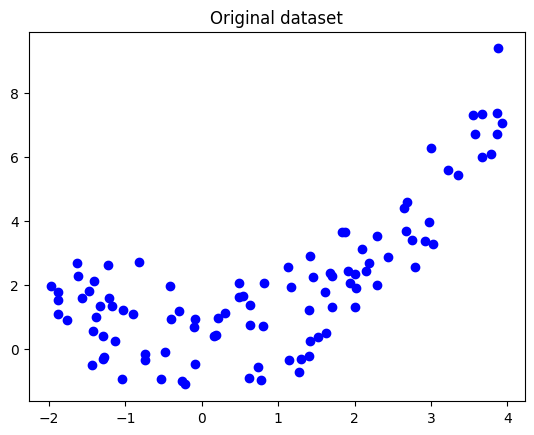

In [70]:
plt.scatter(X,y,color='blue')
plt.title("Original dataset")

In [71]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=0)

In [72]:
slr = LinearRegression()
slr.fit(X_train, y_train)

LinearRegression()

In [73]:
y_pred = slr.predict(X_test)

In [74]:
mse_lr = mean_squared_error(y_test,y_pred)
mse_lr

2.6057683644310012

In [75]:
r2_lr = metrics.r2_score(y_test,y_pred)
r2_lr

0.4734508548755515

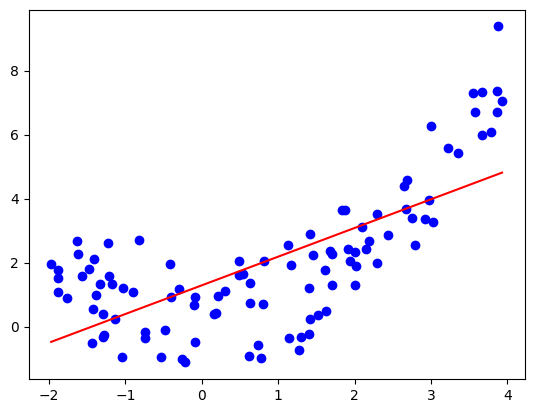

In [76]:
plt.scatter(X,y, color='blue')
X_sorted = np.sort(X, axis=0)
plt.plot(X_sorted, slr.predict(X_sorted), color='red')

In [78]:
# Polynomial Regression
#from sklearn.linear_model import LinearRegression,PolynomialFeatures
poly = PolynomialFeatures(degree = 2)
X_p = poly.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_p, y, test_size=0.2, random_state=0)



In [79]:
plr =LinearRegression()
plr.fit(X_train_p,y_train_p)

LinearRegression()

In [80]:
y_pred_p = plr.predict(X_test_p)

In [81]:
metrics.mean_squared_error(y_test_p,y_pred_p)

1.0285467801527355

In [82]:
metrics.r2_score(y_test_p,y_pred_p)

0.7921609475337279

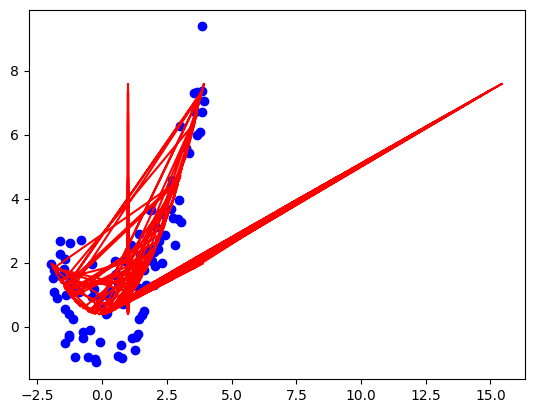

In [83]:
plt.scatter(X,y,color='blue')
plt.plot(X_train_p, plr.predict(X_train_p), color='red')

/tmp/ipykernel_41765/1464688406.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


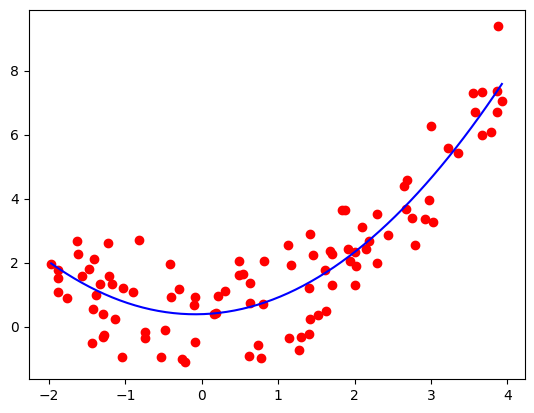

In [85]:
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape(-1, 1)

plt.scatter(X, y, color='red')
plt.plot(X_grid, plr.predict(poly.transform(X_grid)), color='blue')